
# **<font color='green'>Title: Maximizing Revenue for Taxi Drivers Through Payment Type Analysis</font>**

![maximizing car revenue.jpg](<attachment:maximizing car revenue.jpg>)
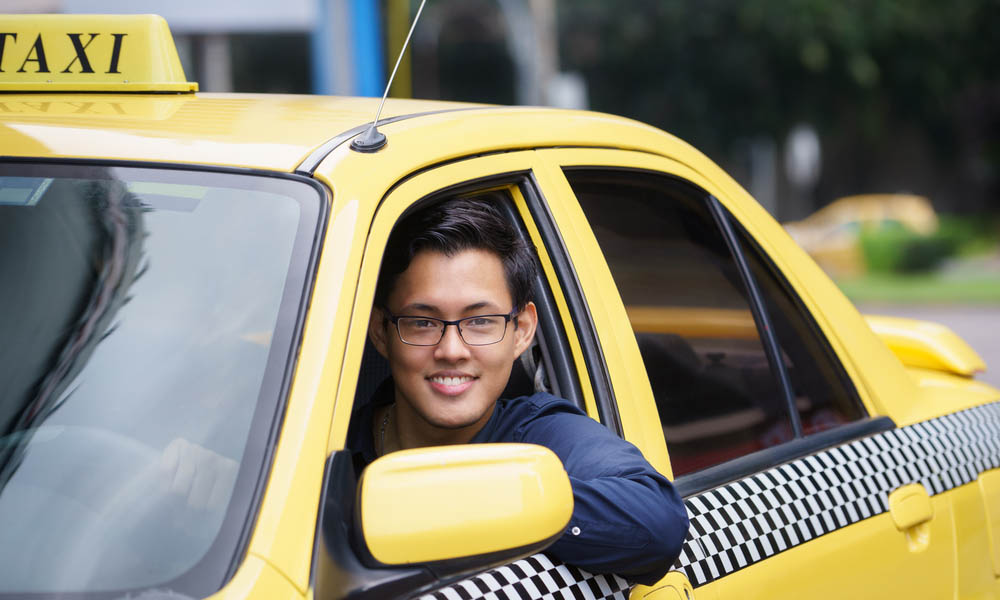

## **<font color=green>Author : Muhammad Adil Naeem</font>**

## **<font color=green>Contact : madilnaeem0@gmail.com</font>**

<br>

[![GitHub](https://img.shields.io/badge/GitHub-Profile-orange?style=for-the-badge&logo=github)](https://github.com/muhammadadilnaeem)

[![Twitter/X](https://img.shields.io/badge/Twitter-Profile-green?style=for-the-badge&logo=twitter)](https://twitter.com/adilnaeem0)

[![LinkedIn](https://img.shields.io/badge/LinkedIn-Profile-blue?style=for-the-badge&logo=linkedin)](https://www.linkedin.com/in/muhammad-adil-naeem-26878b2b9/)
<br>

# **<font color='green'>Problem Statement</font>**


- In the rapidly evolving taxi booking industry, optimizing revenue is crucial for sustained success and driver satisfaction. Our objective is to leverage data-driven insights to enhance revenue streams for taxi drivers. 
- This research focuses on exploring the potential influence of payment methods on fare pricing, specifically examining the relationship between payment type and fare amount.


# **<font color='green'>About Dataset</font>**

- This dataset is taken from [kaggle](https://www.kaggle.com/datasets/gauravpathak1789/yellow-tripdata-2020-01).

The **Yellow Trip Data (January 2020)** 🚖 dataset from Kaggle contains detailed information about taxi trips in New York City. Here's a description of its 18 features in tabular form:

| **Feature Name**         | **Description**                                                                                 |
|--------------------------|-----------------------------------------------------------------------------------------------|
| `VendorID`               | Unique identifier for the taxi company (1 = Creative Mobile Technologies, 2 = VeriFone Inc).   |
| `tpep_pickup_datetime`    | Date and time when the trip started.                                                           |
| `tpep_dropoff_datetime`   | Date and time when the trip ended.                                                             |
| `passenger_count`         | Number of passengers in the taxi (default is 1 if not specified).                             |
| `trip_distance`           | Total distance of the trip in miles.                                                           |
| `RatecodeID`              | Rate code for the trip (e.g., 1 = Standard rate, 2 = JFK, 3 = Newark, 4 = Nassau or Westchester, 5 = Negotiated Fare, 6 = Group Ride ).                  |
| `store_and_fwd_flag`      | Indicates if the trip data was stored before sending (Y = Yes, N = No).                        |
| `PULocationID`            | Pickup location ID based on NYC Taxi Zone Lookup.                                              |
| `DOLocationID`            | Drop-off location ID based on NYC Taxi Zone Lookup.                                            |
| `payment_type`            | Payment method used (1 = Credit card, 2 = Cash, 3 = No charge, 4 = Dispute, 5 = Unknown, 6 = Voided Trip).            |
| `fare_amount`             | Base fare for the trip.                                                                        |
| `extra`                   | Additional charges (e.g., rush hour, overnight surcharges).                                    |
| `mta_tax`                 | MTA tax of $0.50 mandated for all trips.                                                       |
| `tip_amount`              | Tip amount given by the passenger (only for credit card payments).                             |
| `tolls_amount`            | Total tolls paid during the trip.                                                              |
| `improvement_surcharge`   | A $0.30 surcharge added to improve transportation infrastructure.                             |
| `total_amount`            | Total amount charged to the passenger (fare + extras + tolls + tips + surcharges).             |
| `congestion_surcharge`    | A congestion surcharge ($2.50 for taxis) applied for trips below 96th Street in Manhattan.     |


# **<font color='green'>Aims and Objective</font>**

- For this analysis, we employed the extensive dataset of NYC taxi trip records. We will conduct data cleaning and feature engineering to focus exclusively on the relevant columns necessary for our investigation.

- We need to answer the Following Questions

  - Is there a relationship between the total fare amount and payment type?

  - Can we encourage customers to choose payment methods that yield higher revenue for drivers without compromising the customer experience?



# **<font color='green'>Import Libraries and Dataset</font>**

### **Import Libraries**

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

### **Load the Dataet**

In [2]:
df = pd.read_csv("../data/yellow_tripdata_2020-01.csv")

### **View First 5 Rows of Data**

In [3]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


# **<font color='green'>Exploratory Data Analysis</font>**

#### **Shape of the Data**

In [4]:
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns.")

There are 6405008 rows and 18 columns.


#### **Check Datatype Of Columns**

In [5]:
df.dtypes

VendorID                 float64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type             float64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
dtype: object

- Since `tpep_pickup_datetime` and `tpep_dropoff_datetime` have datatype *object* that is not correct.
- We need to change their datatype to `datetime`.

####  **Change datatype of `tpep_pickup_datetime` and `tpep_dropoff_datetime` columns to datetime**

In [6]:
df["tpep_pickup_datetime"] = pd.to_datetime(df['tpep_pickup_datetime'])
df["tpep_dropoff_datetime"] = pd.to_datetime(df['tpep_dropoff_datetime'])
print("Object Data types changed to datetime successfully ✌.")

Object Data types changed to datetime successfully ✌.


In [7]:
# let's check datatypes again
df.dtypes

VendorID                        float64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                    float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
dtype: object

#### **Calculate the trip duration**

- In order to calculate trip duration just subtract: 
```
tpep_dropoff_datetime -  tpep_pickup_datetime  
```


In [8]:
df['trip_duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']

# since we need data in minutes so we can make the following adjustments
df['trip_duration'] = df['trip_duration'].dt.total_seconds()/60

In [9]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,trip_duration
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,4.800000
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,7.416667
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,6.183333
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,4.850000
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,2.300000


### **We will only select columns needed for Analysis**

In [10]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'trip_duration'],
      dtype='object')

In [11]:
df = df[["passenger_count","payment_type","fare_amount","trip_distance","trip_duration"]]
print("Columns for Analysis Selected Successfully 🎯.")

Columns for Analysis Selected Successfully 🎯.


### **Now let's Calculate the Missing Values from the selected Data**

In [12]:
df.isnull().sum()

passenger_count    65441
payment_type       65441
fare_amount            0
trip_distance          0
trip_duration          0
dtype: int64

In [13]:
# now let's calculate the percentage of missing value for further actions
(df.isnull().sum()/len(df))*100

passenger_count    1.021716
payment_type       1.021716
fare_amount        0.000000
trip_distance      0.000000
trip_duration      0.000000
dtype: float64

- Only `1%` of Missing values in the `2` Data.
- We will simply drop these missing rows. 

### **Drop Missing Values**

In [14]:
df.dropna(inplace=True) 
print("Missing Values Dropped Successfully ✌.")

Missing Values Dropped Successfully ✌.


### **Let's Verify the Data Types of Cleaned Data**

In [15]:
df.head()

,passenger_count,payment_type,fare_amount,trip_distance,trip_duration
0,1.0,1.0,6.0,1.2,4.800000
1,1.0,1.0,7.0,1.2,7.416667
2,1.0,1.0,6.0,0.6,6.183333
3,1.0,1.0,5.5,0.8,4.850000
4,1.0,2.0,3.5,0.0,2.300000


- We can observe that `payment_type` and `passenger_count` are in `float`, we need to convert it into `int`.

In [16]:
df['passenger_count'] = df["passenger_count"].astype("int64")
df['payment_type'] = df["payment_type"].astype("int64")
print("Datatypes Changed Successfully ✌.")

Datatypes Changed Successfully ✌.


### **Now Let's Check For Duplicate Values**

In [17]:
print(f"There are {df.duplicated().sum()} Duplicate values in this dataset.")

There are 3331706 Duplicate values in this dataset.


- Since Duplicate values play no role in data analysis, so we will simply drop duplicate values.

In [18]:
df.drop_duplicates(inplace=True)
print("Duplicate Values Dropped Successfully ✌.")

Duplicate Values Dropped Successfully ✌.


### **Let's Check Shape of Data After Data Cleaning**

In [19]:
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns.")

There are 3007861 rows and 5 columns.


### **Let's Check Contribution of `payment_type` and `passenger_count`**

In [20]:
# calculate the percentage of passenger_count values
df['passenger_count'].value_counts(normalize=True)

passenger_count
1    0.581981
2    0.190350
3    0.066360
5    0.062937
6    0.039272
4    0.036046
0    0.023033
7    0.000009
9    0.000006
8    0.000006
Name: proportion, dtype: float64

- `passenger_count` `7`,`8`,`9` are less that `0%` so we will simply drop these values.

In [21]:
df = df[(df["passenger_count"] > 0) & (df["passenger_count"] < 6)]

In [22]:
# calculate the percentage of payment_type values
df['payment_type'].value_counts(normalize=True)

payment_type
1    6.764307e-01
2    3.093476e-01
3    8.654819e-03
4    5.566598e-03
5    3.545604e-07
Name: proportion, dtype: float64

- We only need `payment_type` `1` and `2` for our analysis, as others are present in very less quantity, we will remove them.

In [23]:
df = df[df['payment_type']<3]

- Now we need to change `1` with `Card` and `2` with `Cash` in `payment_type` column.

In [24]:
df['payment_type'].replace([1,2],["Card","Cash"],inplace=True)

In [25]:
df.sample(5)

,passenger_count,payment_type,fare_amount,trip_distance,trip_duration
470047,1,Cash,13.0,2.70,16.366667
598763,5,Card,10.5,1.85,13.433333
374266,1,Card,9.0,1.70,11.766667
2804941,3,Card,52.0,28.81,1389.516667
1633525,1,Card,16.0,4.78,12.766667


### **Check Detailed Description of Numerical Columns**

In [26]:
df.describe()

,passenger_count,fare_amount,trip_distance,trip_duration
count,2.780283e+06,2.780283e+06,2.780283e+06,2.780283e+06
mean,1.733386e+00,1.780567e+01,4.536729e+00,2.415478e+01
std,1.176652e+00,1.506997e+01,4.895890e+00,9.260031e+01
min,1.000000e+00,-5.000000e+02,-2.218000e+01,-2.770367e+03
25%,1.000000e+00,9.000000e+00,1.500000e+00,9.883333e+00
50%,1.000000e+00,1.300000e+01,2.730000e+00,1.573333e+01
75%,2.000000e+00,2.100000e+01,5.470000e+00,2.336667e+01
max,5.000000e+00,4.265000e+03,2.628800e+02,8.525117e+03


- As we can see minimum values of 

|column|value|
|----|----|
|fare_amount|-500.0|
|trip_distance|-22.18|
|trip_duration|-2770.366666666667|

Which should not be negative, so we need to deal with these values.


In [27]:
df = df[df['fare_amount'] > 0]
df = df[df['trip_distance'] > 0]
df = df[df['trip_duration'] > 0]

### **Now we need To Check Outliers**

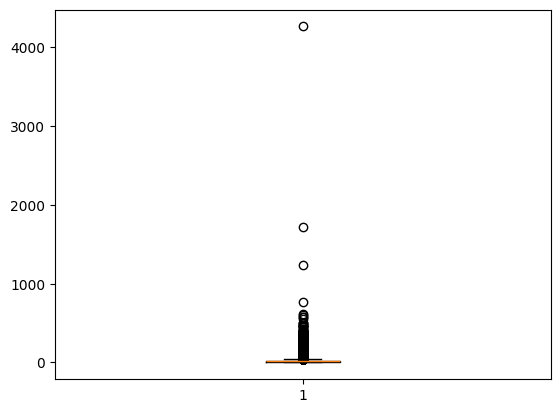

In [28]:
# check outliers in fare_amount
plt.boxplot(df['fare_amount'])
plt.show()

- We can clearly observe that `4000` value is clearly an outlier.
- We will deal with this using `interquartile range`.

### **Remove Outliers Using IQR Method**

In [29]:
# loop through all columns
for col in ["fare_amount","trip_distance","trip_duration"]:
    # calculate Q1
    Q1 = df[col].quantile(0.25)
    # calculate Q3
    Q3 = df[col].quantile(0.75)
    # calculate IQR
    IQR = Q3 - Q1

    # calculate lower bond
    lower_bound = Q1 - 1.5 * IQR
    # calculate upper bond
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col]>lower_bound) & (df[col]<upper_bound)]

### **Now let's observe whether customer prefer to pay by `Cash` or `Card` base on `fare_amount`**

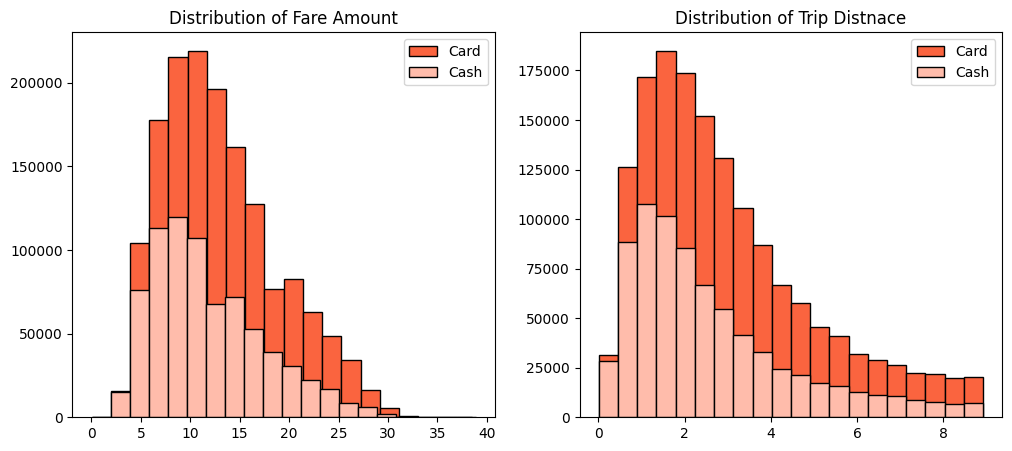

In [30]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Distribution of Fare Amount")
plt.hist(df[df["payment_type"]=="Card"]['fare_amount'], histtype="barstacked", bins=20, edgecolor="k", color="#FA643F", label="Card")
plt.hist(df[df["payment_type"]=="Cash"]['fare_amount'], histtype="barstacked", bins=20, edgecolor="k", color="#FFBCAB", label="Cash")
plt.legend()

plt.subplot(1,2,2)
plt.title("Distribution of Trip Distnace")
plt.hist(df[df["payment_type"]=="Card"]['trip_distance'], histtype="barstacked", bins=20, edgecolor="k", color="#FA643F", label="Card")
plt.hist(df[df["payment_type"]=="Cash"]['trip_distance'], histtype="barstacked", bins=20, edgecolor="k", color="#FFBCAB", label="Cash")
plt.legend()
plt.show()

In [31]:
# now let's understand mean and std of these features
df.groupby("payment_type").agg({"fare_amount" : ["mean","std"], "trip_distance" : ["mean","std"]})

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Card           13.096503  5.831808      2.986372  1.985248
Cash           11.745393  5.597290      2.597434  1.906750

From this observation we can say that : 
- If trip distance `increases` then we can say that `customers` like to pay with `card`.

### **Calculate percentage of customers like to pay with `Card` and `Cash`**

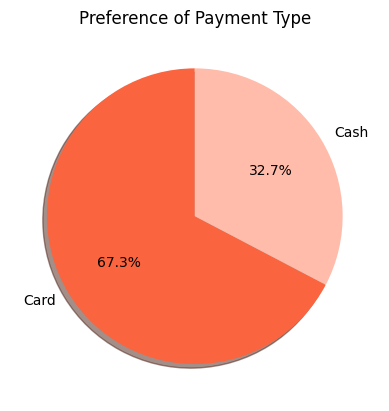

In [32]:
plt.title("Preference of Payment Type")
plt.pie(df["payment_type"].value_counts(normalize=True), labels=df["payment_type"].value_counts().index,
        startangle=90, shadow=True, autopct="%1.1f%%",colors=["#FA643F","#FFBCAB"])
plt.show()

- `67.3%` of passangers are used to pay with `Card`.
- `32.7%` of passangers are used to pay with `Cash`.

### **Calculate Preference of `passenger_count` on `payment_type`**

In [33]:
passenger_count = df.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns = {"passenger_count" : "count"},inplace=True)
passenger_count.reset_index(inplace=True)

In [34]:
passenger_count["percent"] = (passenger_count["count"]/passenger_count["count"].sum()) * 100

In [35]:
passenger_count

,payment_type,passenger_count,count,percent
0,Card,1,907993,39.553452
1,Card,2,327436,14.263573
2,Card,3,122338,5.329215
3,Card,4,63635,2.772030
4,Card,5,123948,5.399349
5,Cash,1,460098,20.042516
6,Cash,2,155392,6.769094
7,Cash,3,54478,2.373138
8,Cash,4,32701,1.424502
9,Cash,5,47591,2.073131


- In order to plot , we need to create a ***custom dataframe*** in which we will store transformed values.

In [36]:
# Create a DataFrame with specific columns: 'payment_type' and five numerical columns (1 to 5)
df_new = pd.DataFrame(columns=['payment_type', 1, 2, 3, 4, 5])

# Assign payment types to the 'payment_type' column
df_new["payment_type"] = ["Card", "Cash"]

# Fill the first row (for 'Card') with passenger counts from the first five rows of 'passenger_count'
df_new.iloc[0, 1:] = passenger_count.iloc[0:5, -1]

# Fill the second row (for 'Cash') with passenger counts from the next five rows of 'passenger_count'
df_new.iloc[1, 1:] = passenger_count.iloc[5:, -1]

# Display the resulting DataFrame
df_new

,payment_type,1,2,3,4,5
0,Card,39.553452,14.263573,5.329215,2.77203,5.399349
1,Cash,20.042516,6.769094,2.373138,1.424502,2.073131


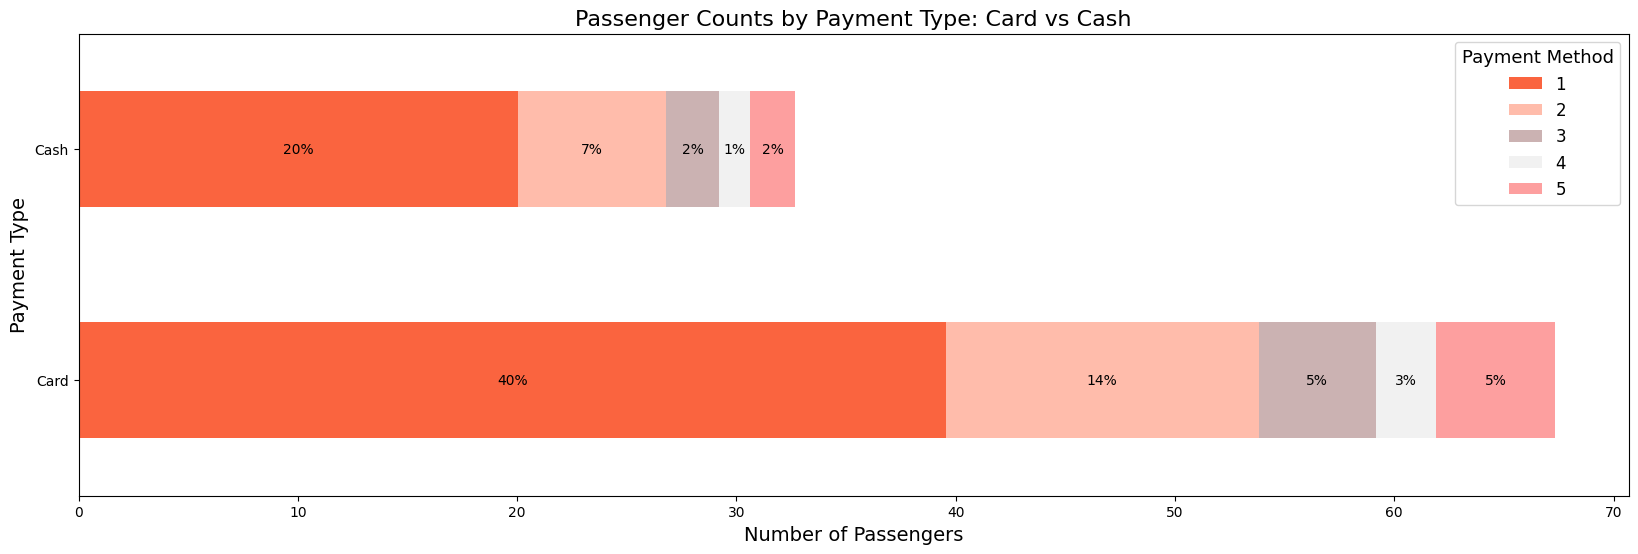

In [37]:
# now we need to plot a stacked barchart

import matplotlib.pyplot as plt

# Assuming df is your DataFrame and already defined
fig, ax = plt.subplots(figsize=(20, 6))

# Plotting the stacked bar chart
df_new.plot(x="payment_type", kind="barh", stacked=True, ax=ax, color=["#FA643F", "#FFBCAB", "#CBB2B2", "#F1F1F1", "#FD9F9F"])

# Adding details to the title and labels
plt.title("Passenger Counts by Payment Type: Card vs Cash", fontsize=16)
plt.xlabel("Number of Passengers", fontsize=14)
plt.ylabel("Payment Type", fontsize=14)

# Adding legend
plt.legend(title="Payment Method", title_fontsize='13', fontsize='12')

# Add percentage text on bars
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
            y + height / 2, 
            '{:.0f}%'.format(width),
            horizontalalignment='center',
            verticalalignment='center')

# Show the plot
plt.show()

# **<font color='green'>Hypothesis Testing</font>**

In order to verify our analysis, we need to perform *Hypothesis Testing*.

- **Null Hypothesis ($H_0$**): There is no difference in ***average fare*** between customers who use `credit cards` and customers who use `cash`.
  
- **Alternative Hypothesis ($H_1$)**: There is a difference in ***average fare*** between customers who use `credit cards` and customers who use `cash`.

### **Plot a `Q-Q Plot` to verify normal distribution of data**

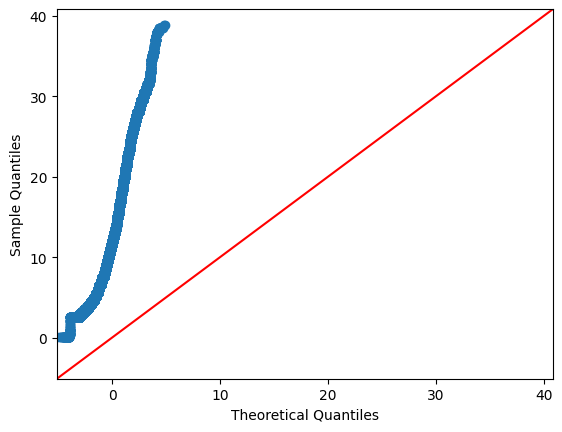

In [38]:
# plot qq-plot using statsmodel library
sm.qqplot(df["fare_amount"], line="45")
plt.show()

- Plot clearly shows that data is `not normaly distributed`.
- We can not use `z-Test`, as it requires normal distribution.
- We need to use `t-Test` for statistical Analysis.

In [39]:
# we will create sample's for t-test

card_sample = df[df["payment_type"]=="Card"]["fare_amount"]
cash_sample = df[df["payment_type"]=="Cash"]["fare_amount"]

### **Perform t-Test on Samples**

In [40]:
t_stat, p_value = stats.ttest_ind(a=card_sample, b=cash_sample, equal_var=False)
print(f"\nT-Statistic: {t_stat}")
print(f"\nP-Value: {p_value}")

# Hypothesis testing decision
alpha = 0.05  # significance level
if p_value < alpha:
    print("\nReject the null hypothesis ($H_0$): There is a significant difference in average fare.")
else:
    print("\nFail to reject the null hypothesis ($H_0$): There is no significant difference in average fare.")


T-Statistic: 169.19783114904993

P-Value: 0.0

Reject the null hypothesis ($H_0$): There is a significant difference in average fare.


# **<font color='green'>Regression Analysis</font>**

In [41]:
# Prepare the data for linear regression
X = df[['trip_duration']]  # Independent variable
y = df['fare_amount']      # Dependent variable

In [42]:
# Initialize the linear regression model
model = LinearRegression()

In [43]:
# Fit the model
model.fit(X, y)

LinearRegression()

In [44]:
# Get the coefficients
intercept = model.intercept_
slope = model.coef_[0]

print(f"Intercept: {intercept}")
print(f"Slope: {slope}")

Intercept: 2.533818037279371
Slope: 0.6912964013134685


In [45]:
# Predict fare amount based on trip duration
df['predicted_fare_amount'] = model.predict(X)

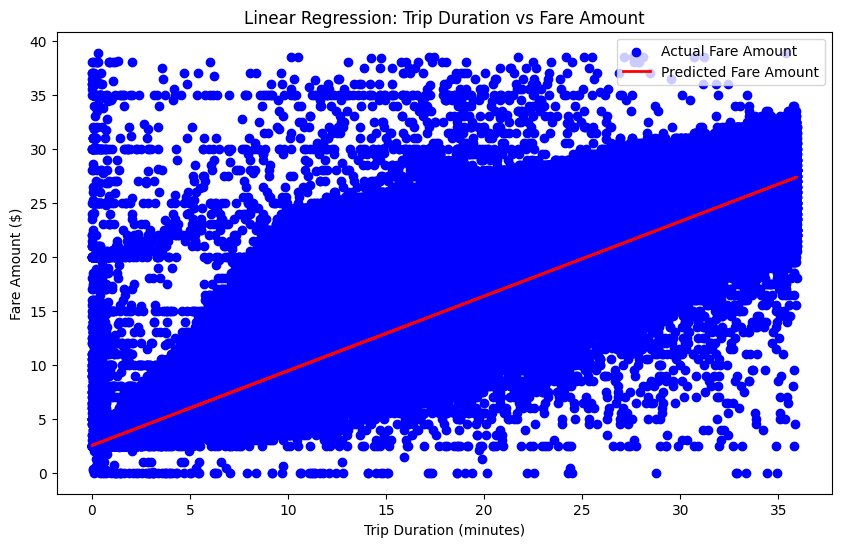

In [46]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(df['trip_duration'], df['fare_amount'], color='blue', label='Actual Fare Amount')
plt.plot(df['trip_duration'], df['predicted_fare_amount'], color='red', linewidth=2, label='Predicted Fare Amount')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.title('Linear Regression: Trip Duration vs Fare Amount')
plt.legend()
plt.show()

---